σ_x = 10.51 ± 0.04 px
σ_y = 10.32 ± 0.04 px
FWHM_x = 24.75 px,  FWHM_y = 24.31 px


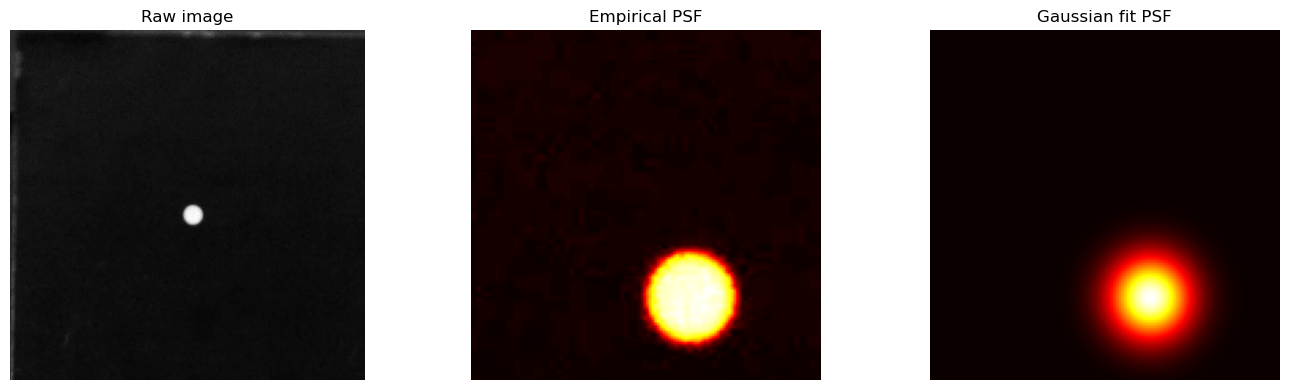

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.optimize import curve_fit
from PIL import Image

img = np.array(Image.open("/Users/sharonchan/Documents/pinhole_sample.png").convert("L"), dtype=np.float64)

# Find the centroid of the bright spot
cx, cy = ndimage.center_of_mass(img)          # (row, col)

# Crop region around the spot
half = 64
r0, r1 = int(cx) - half, int(cx) + half
c0, c1 = int(cy) - half, int(cy) + half
crop = img[r0:r1, c0:c1]

# Subtract background & clip negatives
bg = np.percentile(crop, 5) # takes lowest 5% pixels as bg
crop = np.clip(crop - bg, 0, None) # subtract bg value from every pixel, anything negative is clipped to 0

# Normalise so the PSF sums to 1
# psf is a 2d array of floats
psf = crop / crop.sum()     # actual psf from picture

# Construct a perfect, aberration free psf
# xy is a coordinate grid
def gaussian_2d(xy, amp, x0, y0, sigma_x, sigma_y, offset):
    x, y = xy
    return (offset + amp * np.exp(
        -((x - x0)**2 / (2 * sigma_x**2) +  # how far each pixel is from center in x
          (y - y0)**2 / (2 * sigma_y**2))   # how far each pixel is from center in y
    )).ravel()
# .ravel() flattens 2D to 1D

def fit_gaussian_psf(psf, match_peak=None):
    """Returns popt = [amp, x0, y0, sigma_x, sigma_y, offset]"""
    y_idx, x_idx = np.indices(psf.shape)
    psf_norm = psf / psf.sum()

    cy0, cx0 = ndimage.center_of_mass(psf)  # center
    sx0 = np.sqrt(np.sum(psf_norm * (x_idx - cx0)**2))  # wide - x
    sy0 = np.sqrt(np.sum(psf_norm * (y_idx - cy0)**2))  # wide - y

    # safeguard
    sx0 = max(sx0, 0.5)
    sy0 = max(sy0, 0.5)

    p0 = [psf.max(), cx0, cy0, sx0, sy0, 0.0]
    bounds = (
        [0,   0,   0,   0.3, 0.3, -0.01],
        [np.inf, psf.shape[1], psf.shape[0], psf.shape[1], psf.shape[0], 0.01]
    )

    try:    # scipy
        popt, pcov = curve_fit(
            gaussian_2d, (y_idx, x_idx), psf.ravel(),
            p0=p0, bounds=bounds, maxfev=50_000
        )
        perr = np.sqrt(np.diag(pcov))
    except RuntimeError as e:
        print(f"Gaussian fit failed: {e}")
        print("Falling back to moment-based estimates.")
        popt, perr = np.array(p0), np.full(6, np.nan)

    # Build the fitted Gaussian image
    psf_gauss = gaussian_2d((y_idx, x_idx), *popt).reshape(psf.shape)
    psf_gauss = np.clip(psf_gauss, 0, None)
    psf_gauss /= psf_gauss.sum()            # normalise first

    if match_peak is not None:
        psf_gauss = psf_gauss * (match_peak / psf_gauss.max())  # rescale peak

    return psf_gauss, popt, perr

psf_gauss, popt, perr = fit_gaussian_psf(psf, match_peak=psf.max())
print(f"σ_x = {popt[3]:.2f} ± {perr[3]:.2f} px")
print(f"σ_y = {popt[4]:.2f} ± {perr[4]:.2f} px")
print(f"FWHM_x = {2.355*popt[3]:.2f} px,  FWHM_y = {2.355*popt[4]:.2f} px")

np.save("psf_empirical.npy", psf)
np.save("psf_gaussian.npy",  psf_gauss)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img,       cmap="gray");      axes[0].set_title("Raw image")
axes[1].imshow(psf,       cmap="hot");       axes[1].set_title("Empirical PSF")
axes[2].imshow(psf_gauss, cmap="hot");       axes[2].set_title("Gaussian fit PSF")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("psf_comparison.png", dpi=150)
plt.show()

Estimated radius from HM: 16.25 px
Top Hat PSF Area:     0.796719489398966
Residual Area:        0.10846061871642448
Criteria 1 Error:     13.61%
Passes (within 10%): False


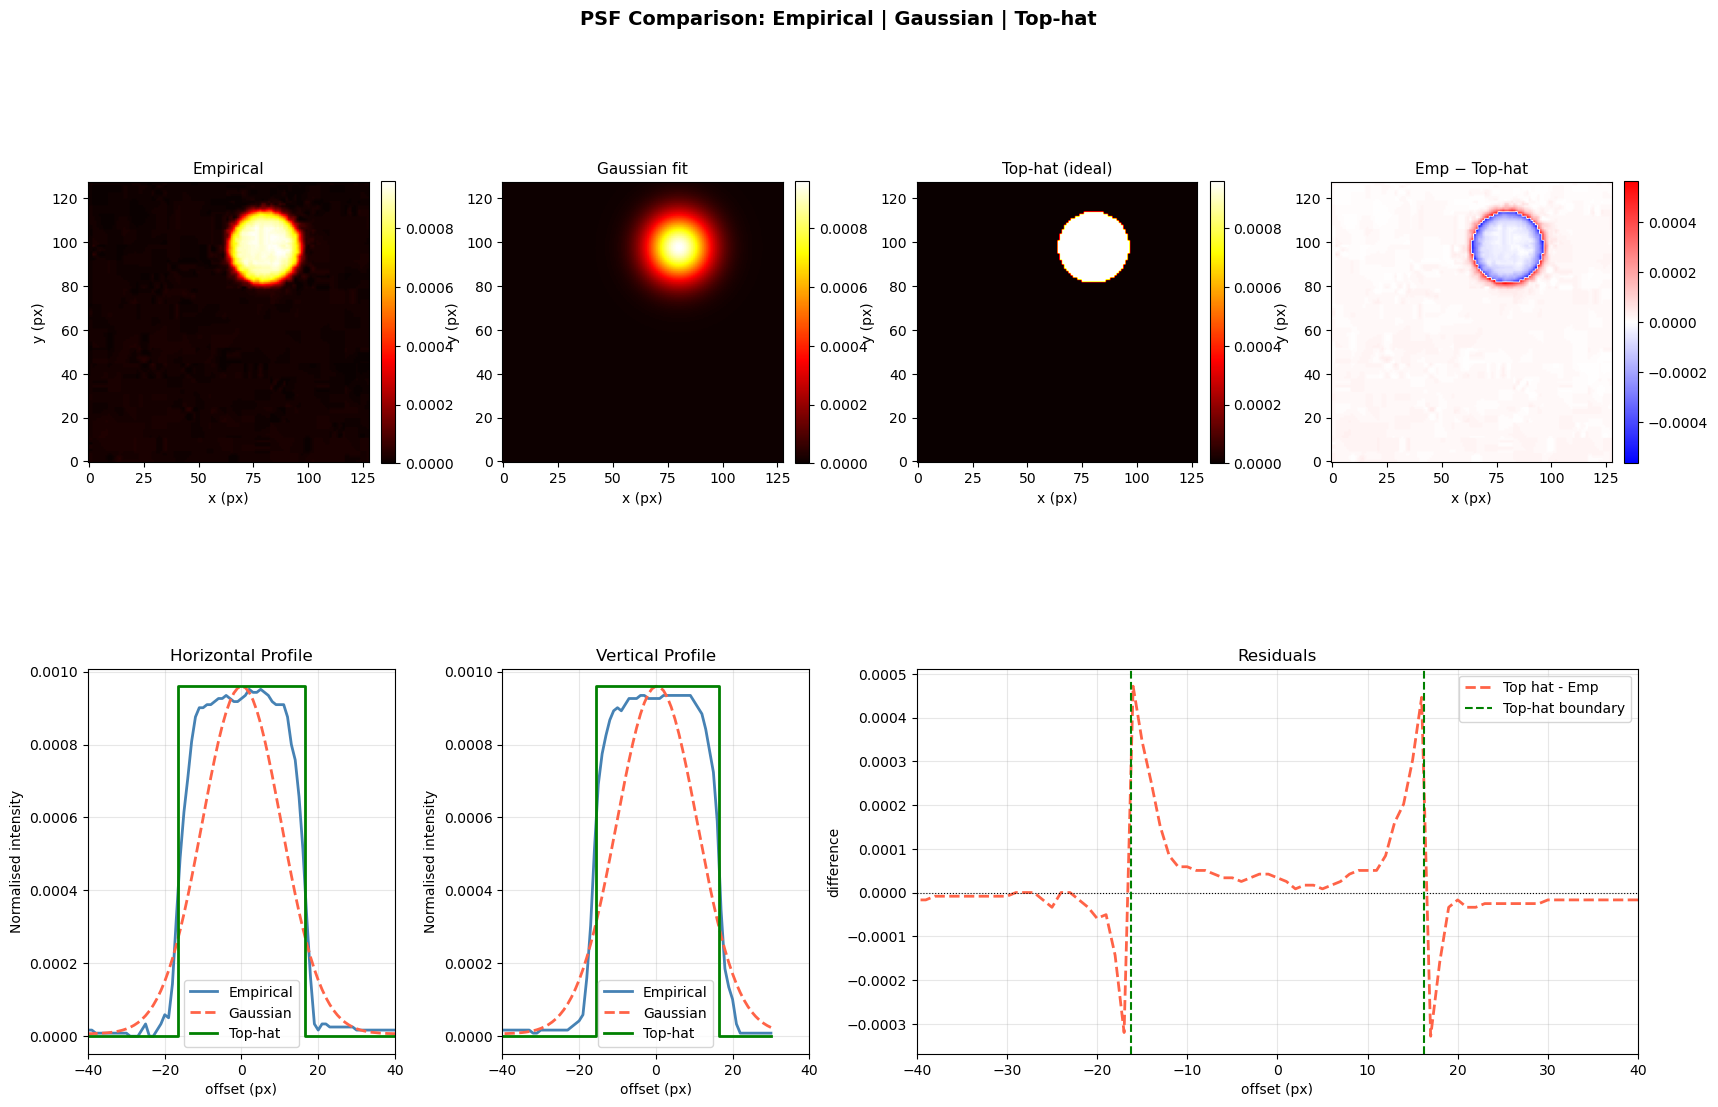

In [ ]:
def make_tophat_psf(shape, cx, cy, radius, match_peak=None):
    y_idx, x_idx = np.indices(shape)
    dist = np.sqrt((x_idx - cx)**2 + (y_idx - cy)**2)

    tophat = (dist <= radius).astype(np.float64)   # 1 inside, 0 outside
    tophat /= tophat.sum()                          # normalise to sum = 1

    if match_peak is not None:
        tophat = tophat * (match_peak / tophat.max())  # rescale peak

    return tophat


# find center from empirical psf
threshold = psf.max() * 0.1   # only use pixels > 10% of peak
masked_psf = np.where(psf > threshold, psf, 0)
cy0, cx0 = ndimage.center_of_mass(masked_psf)

# find pixels above 50% of peak → radius ≈ sqrt(count / π)
above_half = psf > (psf.max() * 0.5)
radius_px  = np.sqrt(above_half.sum() / np.pi)
print(f"Estimated radius from HM: {radius_px:.2f} px")

# Build tophat
psf_tophat = make_tophat_psf(psf.shape, cx0, cy0, radius_px, match_peak=psf.max())

# Plots
# residual_emp_th  = psf        - psf_tophat
# residual_gau_th  = psf_gauss  - psf_tophat
# residual_th_gau = psf_tophat - psf_gauss
#residual_emp_gau = psf - psf_gauss
residual_th_emp = psf_tophat - psf

fig = plt.figure(figsize=(20, 12))
fig.suptitle("PSF Comparison: Empirical | Gaussian | Top-hat", fontsize=14, fontweight="bold")
gs  = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.35)

# ── Row 1: 2D images ──────────────────────────────────────────────────────────
titles = ["Empirical", "Gaussian fit", "Top-hat (ideal)", "Emp − Top-hat"]
images = [psf, psf_gauss, psf_tophat, residual_emp_th]
cmaps  = ["hot", "hot", "hot", "bwr"]

for i, (title, data, cmap) in enumerate(zip(titles, images, cmaps)):
    ax = fig.add_subplot(gs[0, i])
    vmax = np.abs(data).max()
    vmin = -vmax if cmap == "bwr" else 0
    im = ax.imshow(data, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Row 2: 1D profiles through centre ─────────────────────────────────────────
cy_i = int(round(cy0))   
cx_i = int(round(cx0))

x_ax = np.arange(psf.shape[1]) - cx_i
y_ax = np.arange(psf.shape[0]) - cy_i

ax_h = fig.add_subplot(gs[1, 0])   # horizontal profile
ax_v = fig.add_subplot(gs[1, 1])     # vertical profile
ax_r = fig.add_subplot(gs[1, 2:4])     # residuals

for ax, prof_ax, label in [(ax_h, x_ax, "Horizontal"), (ax_v, y_ax, "Vertical")]:
    emp = psf[cy_i, :]    if label == "Horizontal" else psf[:, cx_i]
    gau = psf_gauss[cy_i, :] if label == "Horizontal" else psf_gauss[:, cx_i]
    th  = psf_tophat[cy_i, :] if label == "Horizontal" else psf_tophat[:, cx_i]

    ax.plot(prof_ax, emp, color="steelblue", lw=2,              label="Empirical")
    ax.plot(prof_ax, gau, color="tomato",    lw=2, ls="--",     label="Gaussian")
    ax.step(prof_ax, th,  color="green",     lw=2, where="mid", label="Top-hat")
    ax.set_title(f"{label} Profile")
    ax.set_xlabel("offset (px)"); ax.set_ylabel("Normalised intensity")
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlim(-40, 40) 

# Criteria 1 - The volume under the curve of ADU (Analog-to-Digital Unit) vs. x and y. This must be within 10% of a PSF model with infinite slope.

res_th_emp_2d = psf_tophat - psf

tophat_mask = psf_tophat > 0

psf_tophat_masked = psf_tophat * tophat_mask
res_masked = np.abs(res_th_emp_2d) * tophat_mask

th_area = np.trapezoid(np.trapezoid(psf_tophat_masked, axis=1), axis=0)
cri1_res_area = np.trapezoid(np.trapezoid(res_masked, axis=1), axis=0)
cri1_error = cri1_res_area / th_area

print("Top Hat PSF Area:    ", th_area)
print("Residual Area:       ", cri1_res_area)
print("Criteria 1 Error:    ", f"{cri1_error * 100:.2f}%")
print("Passes (within 10%):", cri1_error < 0.10)

# top hat boundaries

tophat_cols = np.any(tophat_mask, axis=0)  # True for each column that has tophat coverage
x_indices   = np.where(tophat_cols)[0]

x_left  = x_indices[0]
x_right = x_indices[-1]

# Residuals: both Empirical and Gaussian vs Top-hat

# res_emp = psf[cy_i, :]   - psf_tophat[cy_i, :]
# res_gau = psf_gauss[cy_i, :] - psf_tophat[cy_i, :]
# res_emp_gau = psf[cy_i, :] - psf_gauss[cy_i, :]
res_th_emp = psf_tophat[cy_i, :] - psf[cy_i, :]

# ax_r.plot(x_ax, res_emp, color="steelblue", lw=2, label="Emp − Top-hat")
# ax_r.plot(x_ax, res_gau, color="tomato",    lw=2, ls="--", label="Gauss − Top-hat")
# ax_r.plot(x_ax, res_emp_gau, color="orange", lw=2, ls="--", label="Emp − Gauss")
ax_r.plot(x_ax, res_th_emp, color="tomato", lw=2, ls="--", label="Top hat - Emp")

ax_r.axhline(0, color="black", lw=0.8, ls=":")
ax_r.set_title("Residuals")
ax_r.set_xlabel("offset (px)"); ax_r.set_ylabel("difference")
ax_r.axvline(x=-radius_px, color="green", lw=1.5, ls="--", label="Top-hat boundary")
ax_r.axvline(x=+radius_px, color="green", lw=1.5, ls="--")
ax_r.legend(); ax_r.grid(alpha=0.3)
ax_r.set_xlim(-40, 40) 

plt.savefig("psf_tophat_analysis.png", dpi=150, bbox_inches="tight")
plt.show()